# How to build a linear factor model

Algorithmic trading strategies use linear factor models to quantify the relationship between the return of an asset and the sources of risk that represent the main drivers of these returns. Each factor risk carries a premium, and the total asset return can be expected to correspond to a weighted average of these risk premia.

There are several practical applications of factor models across the portfolio management process from construction and asset selection to risk management and performance evaluation. The importance of factor models continues to grow as common risk factors are now tradeable:

- A summary of the returns of many assets by a much smaller number of factors reduces the amount of data required to estimate the covariance matrix when optimizing a portfolio
- An estimate of the exposure of an asset or a portfolio to these factors allows for the management of the resultant risk, for instance by entering suitable hedges when risk factors are themselves traded
- A factor model also permits the assessment of the incremental signal content of new alpha factors
- A factor model can also help assess whether a manager's performance relative to a benchmark is indeed due to skill in selecting assets and timing the market, or if instead, the performance can be explained by portfolio tilts towards known return drivers that can today be replicated as low-cost, passively managed funds without incurring active management fees

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os

from statsmodels.api import OLS, add_constant
import pandas_datareader.data as web

from linearmodels.asset_pricing import LinearFactorModel

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style('whitegrid')

## Get data

Fama and french make update risk factor and research portfolio data availabel through their website and you can use the pandas datareader package to obtin the data.

### Risk Factors

In particular, we will be using the five Fama—French factors that result from sorting stocks first into three size groups and then into two for each of the remaining three firm-specific factors.

Hence, the factors involve three sets of value-weighted portfolios formed as 3 x 2 sorts on size and book-to-market, size and operating profitability, and size and investment. The risk factor values computed as the average returns of the portfolios (PF) as outlined in the following table:

| Label | Name                     | Description |
|------:|--------------------------|-------------|
| SMB   | Small Minus Big           | Average return on the nine small stock portfolios minus the average return on the nine big stock portfolios |
| HML   | High Minus Low            | Average return on the two value portfolios minus the average return on the two growth portfolios |
| RMW   | Robust Minus Weak         | Average return on the two robust operating profitability portfolios minus the average return on the two weak operating profitability portfolios |
| CMA   | Conservative Minus Aggressive | Average return on the two conservative investment portfolios minus the average return on the two aggressive investment portfolios |
| Rm − Rf | Excess return on the market | Value-weight return of all firms incorporated in the US and listed on the NYSE, AMEX, or NASDAQ at the beginning of month *t* with “good” data for *t* minus the one-month Treasury bill rate |


We will use returns at a daily frequency that we obtain for the period 2010 – 2017 as follows:

In [4]:
ff_factor = 'F-F_Research_Data_5_Factors_2x3_daily'
ff_factor_data = web.DataReader(ff_factor, 'famafrench', start='2010', end='2025-10')[0]
ff_factor_data.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2010-01-04,1.69,0.79,1.14,-0.17,0.21,0.0
2010-01-05,0.31,-0.42,1.22,-0.18,0.18,0.0
2010-01-06,0.13,-0.14,0.55,-0.05,0.20,0.0
2010-01-07,0.40,0.25,0.96,-0.66,0.22,0.0
2010-01-08,0.33,0.31,0.02,0.23,-0.40,0.0


In [5]:
ff_factor_data.describe()

,Mkt-RF,SMB,HML,RMW,CMA,RF
count,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000
mean,0.053868,-0.004761,-0.005839,0.009712,0.000358,0.005228
std,1.125981,0.640285,0.778350,0.477440,0.421608,0.007798
min,-12.010000,-4.580000,-5.030000,-2.230000,-2.920000,0.000000
25%,-0.400000,-0.380000,-0.380000,-0.250000,-0.220000,0.000000
50%,0.080000,-0.010000,-0.030000,0.000000,-0.010000,0.000000
75%,0.590000,0.350000,0.360000,0.260000,0.210000,0.010000
max,9.650000,5.710000,6.730000,4.250000,2.470000,0.020000


## Portfolios

Fama and French also make available numerous portfolios that we can illustrate the estimation of the factor exposures, as well as the value of the risk premia available in the market for a given time period. We will use a panel of the 17 industry portfolios at a daily frequency.

We will subtract the risk-free rate from the returns because the factor model works with excess returns:

In [6]:
ff_portfolio = '17_Industry_Portfolios_daily'
ff_portfolio_data = web.DataReader(ff_portfolio, 'famafrench', start='2010', end='2025-10')[0]
ff_portfolio_data = ff_portfolio_data.sub(ff_factor_data.RF, axis=0)
ff_portfolio_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3961 entries, 2010-01-04 to 2025-10-01
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Food    3961 non-null   float64
 1   Mines   3961 non-null   float64
 2   Oil     3961 non-null   float64
 3   Clths   3961 non-null   float64
 4   Durbl   3961 non-null   float64
 5   Chems   3961 non-null   float64
 6   Cnsum   3961 non-null   float64
 7   Cnstr   3961 non-null   float64
 8   Steel   3961 non-null   float64
 9   FabPr   3961 non-null   float64
 10  Machn   3961 non-null   float64
 11  Cars    3961 non-null   float64
 12  Trans   3961 non-null   float64
 13  Utils   3961 non-null   float64
 14  Rtail   3961 non-null   float64
 15  Finan   3961 non-null   float64
 16  Other   3961 non-null   float64
dtypes: float64(17)
memory usage: 557.0 KB


In [7]:
ff_portfolio_data.describe()

,Food,Mines,Oil,Clths,Durbl,Chems,Cnsum,Cnstr,Steel,FabPr,Machn,Cars,Trans,Utils,Rtail,Finan,Other
count,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000
mean,0.032391,0.035006,0.034618,0.043244,0.032780,0.031987,0.045572,0.069336,0.043580,0.066221,0.074971,0.084577,0.052714,0.040447,0.056746,0.053181,0.059563
std,0.909525,1.763835,1.760090,1.589269,1.417691,1.458240,0.923485,1.405997,2.014471,1.399315,1.513526,1.991437,1.287553,1.084229,1.146979,1.386372,1.178882
min,-10.060000,-11.920000,-20.000000,-13.750000,-14.190000,-11.820000,-7.830000,-18.840000,-14.530000,-11.930000,-13.060000,-14.480000,-13.360000,-11.660000,-8.800000,-14.640000,-11.990000
25%,-0.410000,-0.930000,-0.800000,-0.730000,-0.700000,-0.720000,-0.390000,-0.620000,-1.040000,-0.620000,-0.620000,-0.790000,-0.530000,-0.490000,-0.490000,-0.550000,-0.430000
50%,0.050000,0.060000,0.040000,0.080000,0.080000,0.070000,0.060000,0.110000,0.060000,0.070000,0.110000,0.100000,0.100000,0.080000,0.090000,0.070000,0.090000
75%,0.520000,1.020000,0.890000,0.860000,0.800000,0.830000,0.530000,0.810000,1.100000,0.790000,0.830000,1.000000,0.700000,0.590000,0.640000,0.740000,0.640000
max,7.860000,13.610000,16.090000,14.090000,10.740000,10.380000,8.160000,14.080000,12.380000,13.110000,15.580000,16.640000,12.290000,11.770000,9.380000,13.160000,9.880000


## Equity data

In [8]:
with pd.HDFStore(os.path.join("..", "..", "data", "assets.h5")) as store:
    prices = store["prices/chile"].loc["2010" : "2025-10"]
    
prices = prices.dropna(how="all", axis = 1) # removes columns with all nan values
returns = prices.pct_change().mul(100)
returns = returns.dropna(how = 'all').dropna(axis = 1)
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4128 entries, 2010-01-04 to 2025-10-31
Data columns (total 89 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NAVARINO.SN    4128 non-null   float64
 1   VOLCAN.SN      4128 non-null   float64
 2   ENAEX.SN       4128 non-null   float64
 3   CIC.SN         4128 non-null   float64
 4   MOLYMET.SN     4128 non-null   float64
 5   BSANTANDER.SN  4128 non-null   float64
 6   PAZ.SN         4128 non-null   float64
 7   MULTI-X.SN     4128 non-null   float64
 8   RIPLEY.SN      4128 non-null   float64
 9   MARINSA.SN     4128 non-null   float64
 10  MASISA.SN      4128 non-null   float64
 11  QUINENCO.SN    4128 non-null   float64
 12  ENELGXCH.SN    4128 non-null   float64
 13  ELECMETAL.SN   4128 non-null   float64
 14  ENJOY.SN       4128 non-null   float64
 15  BANVIDA.SN     4128 non-null   float64
 16  DUNCANFOX.SN   4128 non-null   float64
 17  SK.SN          4128 non-null   flo

### align data

In [9]:
ff_factor_data = ff_factor_data.reindex(returns.index)
ff_portfolio_data = ff_portfolio_data.reindex(returns.index)

In [10]:
ff_factor_data = ff_factor_data.fillna(ff_factor_data.median())
ff_portfolio_data = ff_portfolio_data.fillna(ff_portfolio_data.median())

In [11]:
ff_factor_data.describe()

,Mkt-RF,SMB,HML,RMW,CMA,RF
count,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,0.054925,-0.004973,-0.006817,0.009319,-0.000061,0.005017
std,1.102976,0.627197,0.762454,0.467685,0.412995,0.007708
min,-12.010000,-4.580000,-5.030000,-2.230000,-2.920000,0.000000
25%,-0.370000,-0.360000,-0.360000,-0.240000,-0.210000,0.000000
50%,0.080000,-0.010000,-0.030000,0.000000,-0.010000,0.000000
75%,0.560000,0.340000,0.340000,0.250000,0.190000,0.010000
max,9.650000,5.710000,6.730000,4.250000,2.470000,0.020000


## Compute excess Returns

In [12]:
excess_returns = returns.sub(ff_factor_data.RF, axis = 0)
excess_returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4128 entries, 2010-01-04 to 2025-10-31
Data columns (total 89 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NAVARINO.SN    4128 non-null   float64
 1   VOLCAN.SN      4128 non-null   float64
 2   ENAEX.SN       4128 non-null   float64
 3   CIC.SN         4128 non-null   float64
 4   MOLYMET.SN     4128 non-null   float64
 5   BSANTANDER.SN  4128 non-null   float64
 6   PAZ.SN         4128 non-null   float64
 7   MULTI-X.SN     4128 non-null   float64
 8   RIPLEY.SN      4128 non-null   float64
 9   MARINSA.SN     4128 non-null   float64
 10  MASISA.SN      4128 non-null   float64
 11  QUINENCO.SN    4128 non-null   float64
 12  ENELGXCH.SN    4128 non-null   float64
 13  ELECMETAL.SN   4128 non-null   float64
 14  ENJOY.SN       4128 non-null   float64
 15  BANVIDA.SN     4128 non-null   float64
 16  DUNCANFOX.SN   4128 non-null   float64
 17  SK.SN          4128 non-null   flo

In [13]:
excess_returns = excess_returns.clip(lower=np.percentile(excess_returns, 0.5),
                                     upper=np.percentile(excess_returns, 99.5))

# Fama-Macbeth Regression

We are doing a pricing test. it isnt causal or preditive.

Given data on risk factors and portfolio returns, it is useful to estimate the portfolio's exposure, that is, how much the risk factors drive portfolio returns, as well as how much the exposure to a given factor is worth, that is, the what market's risk factor premium is. The risk premium then permits to estimate the return for any portfolio provided the factor exposure is known or can be assumed.

In [14]:
ff_portfolio_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4128 entries, 2010-01-04 to 2025-10-31
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Food    4128 non-null   float64
 1   Mines   4128 non-null   float64
 2   Oil     4128 non-null   float64
 3   Clths   4128 non-null   float64
 4   Durbl   4128 non-null   float64
 5   Chems   4128 non-null   float64
 6   Cnsum   4128 non-null   float64
 7   Cnstr   4128 non-null   float64
 8   Steel   4128 non-null   float64
 9   FabPr   4128 non-null   float64
 10  Machn   4128 non-null   float64
 11  Cars    4128 non-null   float64
 12  Trans   4128 non-null   float64
 13  Utils   4128 non-null   float64
 14  Rtail   4128 non-null   float64
 15  Finan   4128 non-null   float64
 16  Other   4128 non-null   float64
dtypes: float64(17)
memory usage: 580.5 KB


In [15]:
ff_factor_data = ff_factor_data.drop('RF', axis=1)
ff_factor_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4128 entries, 2010-01-04 to 2025-10-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  4128 non-null   float64
 1   SMB     4128 non-null   float64
 2   HML     4128 non-null   float64
 3   RMW     4128 non-null   float64
 4   CMA     4128 non-null   float64
dtypes: float64(5)
memory usage: 193.5 KB


To address the inference problem caused by the correlation of the residuals, Fama and MacBeth proposed a two-step methodology for a cross-sectional regression of returns on factors. The two-stage Fama—Macbeth regression is designed to estimate the premium rewarded for the exposure to a particular risk factor by the market. The two stages consist of:

- First stage: N time-series regression, one for each asset or portfolio, of its excess returns on the factors to estimate the factor loadings.

- Second stage: T cross-sectional regression, one for each time period, to estimate the risk premium.


Now we can compute the factor risk premia as the time average and get t-statistic to assess their individual significance, using the assumption that the risk premia estimates are independent over time.

If we had a very large and representative data sample on traded risk factors we could use the sample mean as a risk premium estimate. However, we typically do not have a sufficiently long history to and the margin of error around the sample mean could be quite large.

The Fama—Macbeth methodology leverages the covariance of the factors with other assets to determine the factor premia. The second moment of asset returns is easier to estimate than the first moment, and obtaining more granular data improves estimation considerably, which is not true of mean estimation.

## Step 1 : factor exposures

We can implement the first stage to obtain the 17 factor loading estimates as follows:

In [16]:
betas = []

for industry in ff_portfolio_data:
    step1 = OLS(endog = ff_portfolio_data.loc[ff_factor_data.index, industry],
                exog = add_constant(ff_factor_data)).fit()
    betas.append(step1.params.drop('const'))

In [17]:
betas = pd.DataFrame(betas,
                     columns = ff_factor_data.columns,
                     index = ff_portfolio_data.columns)
betas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, Food to Other
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  17 non-null     float64
 1   SMB     17 non-null     float64
 2   HML     17 non-null     float64
 3   RMW     17 non-null     float64
 4   CMA     17 non-null     float64
dtypes: float64(5)
memory usage: 1.3+ KB


## Step 2: Risk Premia

In the second regression, each industry is one observation, the betas are the features, and the returns at a given date are the target.

In [18]:
lambdas = []
for period in ff_portfolio_data.index : 
    step2 = OLS(endog = ff_portfolio_data.loc[period, betas.index],
                exog = betas).fit()
    lambdas.append(step2.params)

In [19]:
lambdas = pd.DataFrame(lambdas, 
                       index=ff_portfolio_data.index,
                       columns=betas.columns.tolist())
lambdas.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4128 entries, 2010-01-04 to 2025-10-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  4128 non-null   float64
 1   SMB     4128 non-null   float64
 2   HML     4128 non-null   float64
 3   RMW     4128 non-null   float64
 4   CMA     4128 non-null   float64
dtypes: float64(5)
memory usage: 322.5 KB


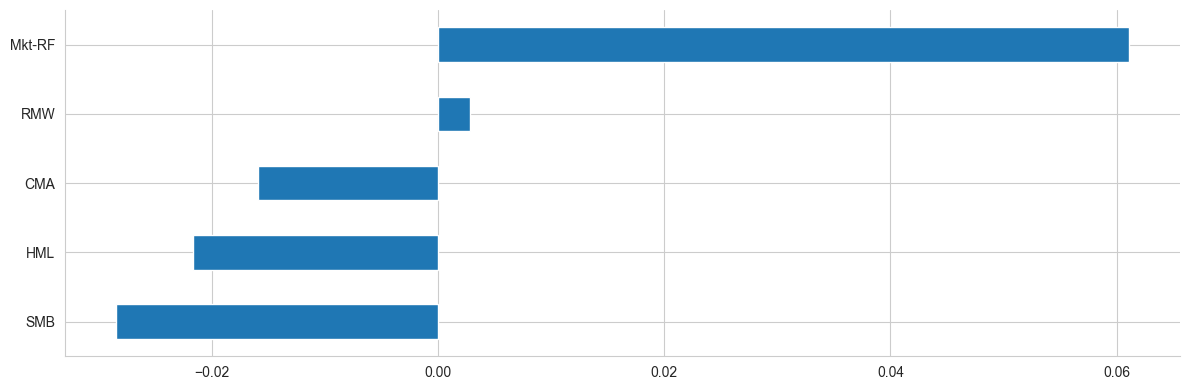

In [20]:
lambdas.mean().sort_values().plot.barh(figsize=(12, 4))
sns.despine()
plt.tight_layout();

In [21]:
t = lambdas.mean().div(lambdas.std())
t

Mkt-RF    0.054664
SMB      -0.023496
HML      -0.021433
RMW       0.001837
CMA      -0.013248
dtype: float64

This t-statistic assesses whether the risk premium is statistically different from zero, that is, whether the factor is priced in the cross-section of returns.

### Result

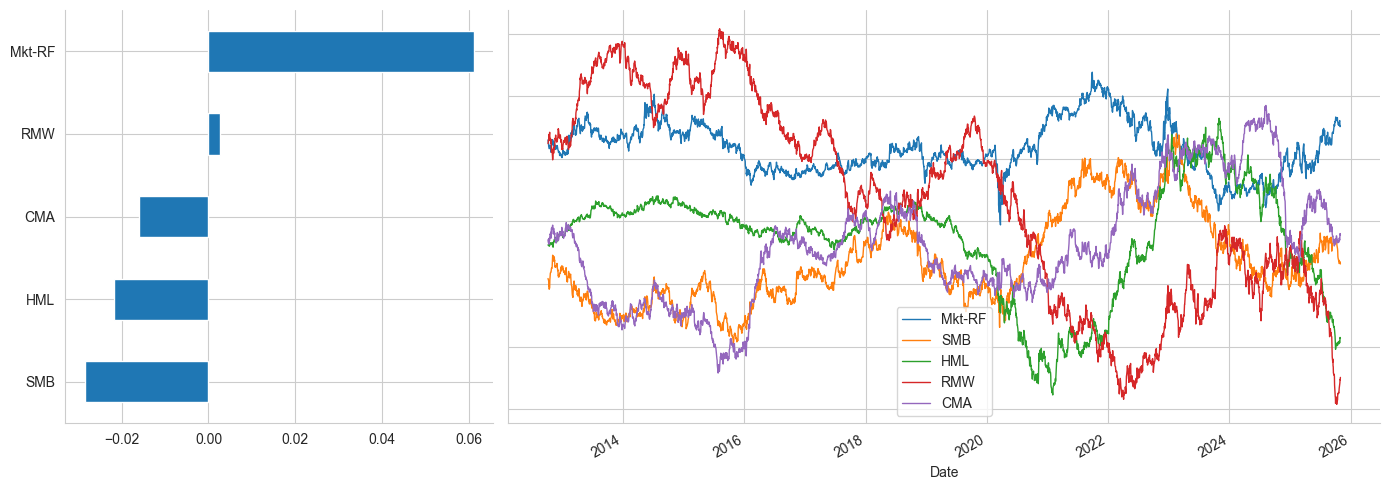

In [24]:
window = 24 * 30
ax1 = plt.subplot2grid((1, 3), (0, 0))
ax2 = plt.subplot2grid((1, 3), (0, 1), colspan=2)
lambdas.mean().sort_values().plot.barh(ax=ax1)
lambdas.rolling(window).mean().dropna().plot(lw=1,
                                             figsize=(14, 5),
                                             sharey=True,
                                             ax=ax2)
sns.despine()
plt.tight_layout()

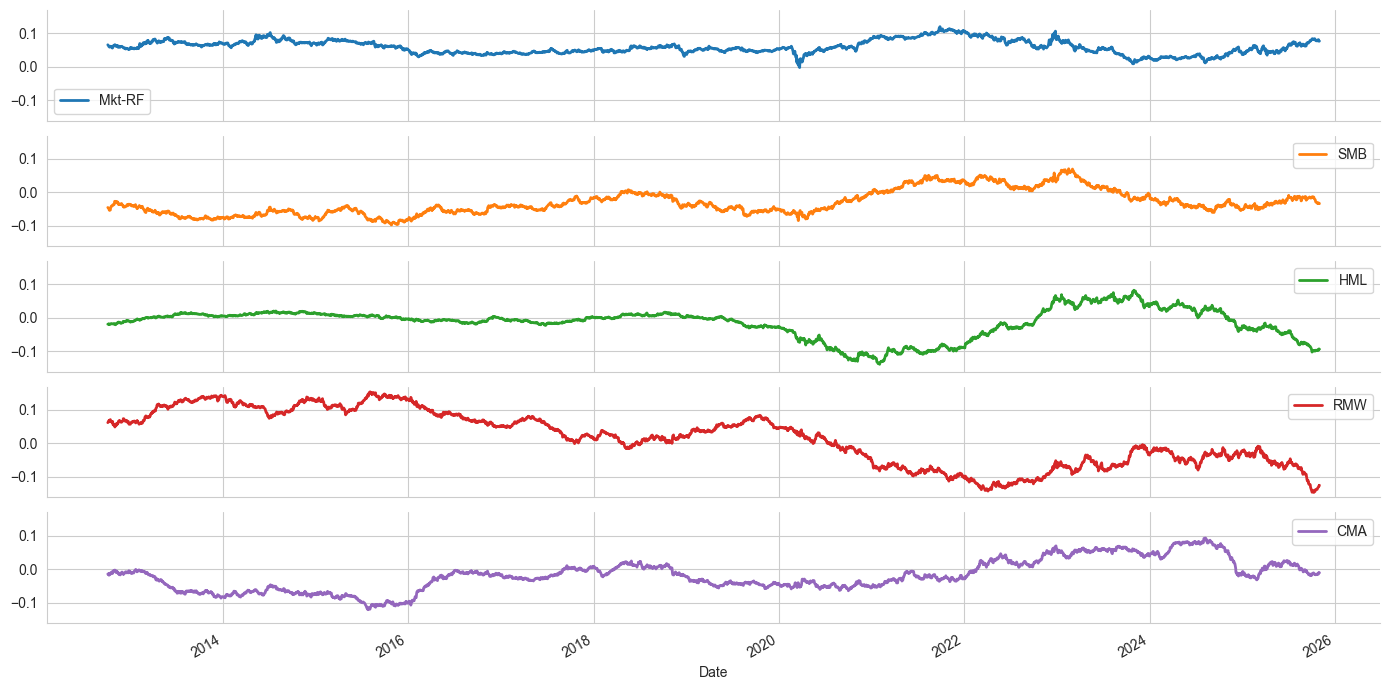

In [25]:
window = 24 * 30
lambdas.rolling(window).mean().dropna().plot(lw=2,
                                             figsize=(14, 7),
                                             subplots=True,
                                             sharey=True)
sns.despine()
plt.tight_layout()

# Fama-Macbeth with the LinearModels library

The linear_models library extends statsmodels with various models for panel data and also implements the two-stage Fama—MacBeth procedure:

In [26]:
mod = LinearFactorModel(portfolios=ff_portfolio_data, 
                        factors=ff_factor_data)
res = mod.fit()
print(res)

                      LinearFactorModel Estimation Summary                      
No. Test Portfolios:                 17   R-squared:                      0.7082
No. Factors:                          5   J-statistic:                    15.690
No. Observations:                  4128   P-value                         0.2059
Date:                  Tue, Jan 06 2026   Distribution:                 chi2(12)
Time:                          21:47:26                                         
Cov. Estimator:                  robust                                         
                                                                                
                            Risk Premia Estimates                             
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Mkt-RF         0.0611     0.0174     3.5067     0.0005      0.0270      0.0953
SMB           -0.0285     0.0190    

In [29]:
print(res.full_summary)

                      LinearFactorModel Estimation Summary                      
No. Test Portfolios:                 17   R-squared:                      0.7082
No. Factors:                          5   J-statistic:                    15.690
No. Observations:                  4128   P-value                         0.2059
Date:                  Tue, Jan 06 2026   Distribution:                 chi2(12)
Time:                          21:47:26                                         
Cov. Estimator:                  robust                                         
                                                                                
                            Risk Premia Estimates                             
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Mkt-RF         0.0611     0.0174     3.5067     0.0005      0.0270      0.0953
SMB           -0.0285     0.0190    

In [30]:
lambdas.mean()

Mkt-RF    0.061131
SMB      -0.028535
HML      -0.021726
RMW       0.002765
CMA      -0.015941
dtype: float64